In [3]:
!pip install yfinance pandas matplotlib seaborn

  Preparing metadata (setup.py) ... one
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 11.7 MB/s eta 0:00:00a 0:00:01
  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15548 sha256=554ae710183aca079b7a134faabfa62492e291d2288ed0456d226fef56fc7be1
  Stored in directory: /Users/ibtissem/Library/Caches/pip/wheels/1e/df/0f/e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking
  Attempting uninstall: cffi0m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/6 [websockets]
    Found e

In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# On choisit 5 actions du CAC 40
tickers = ['TTE.PA', 'BNP.PA', 'AIR.PA', 'MC.PA', 'SAN.PA']
noms = ['TotalEnergies', 'BNP Paribas', 'Airbus', 'LVMH', 'Sanofi']

# Téléchargement des prix de clôture sur 1 an
data = yf.download(tickers, start='2024-01-01', end='2025-01-01')['Close']
data.columns = noms

print(data.tail())

[*********************100%***********************]  5 of 5 completed

            TotalEnergies  BNP Paribas      Airbus       LVMH     Sanofi
Date                                                                    
2024-12-23     150.516586    52.191956  614.463928  87.908089  47.562809
2024-12-24     150.320984    52.282822  616.026428  87.879356  47.709579
2024-12-27     151.885818    53.191456  620.713989  89.344810  48.388401
2024-12-30     150.986038    53.364094  614.561523  89.210716  48.250797
2024-12-31     151.377243    53.809330  620.616333  89.785400  48.957130


In [9]:
# Rendements quotidiens (variation en % chaque jour)
rendements = data.pct_change().dropna()

# Résumé statistique
rendement_annuel = rendements.mean() * 252
volatilite_annuelle = rendements.std() * (252 ** 0.5)

resume = pd.DataFrame({
    'Rendement annuel (%)': (rendement_annuel * 100).round(2),
    'Volatilité annuelle (%)': (volatilite_annuelle * 100).round(2)
})

print(resume)

               Rendement annuel (%)  Volatilité annuelle (%)
TotalEnergies                 13.44                    23.23
BNP Paribas                    2.50                    23.29
Airbus                        -6.88                    28.66
LVMH                           8.65                    17.81
Sanofi                        -9.31                    19.16


AttributeError: 'Axes' object has no attribute 'tick'

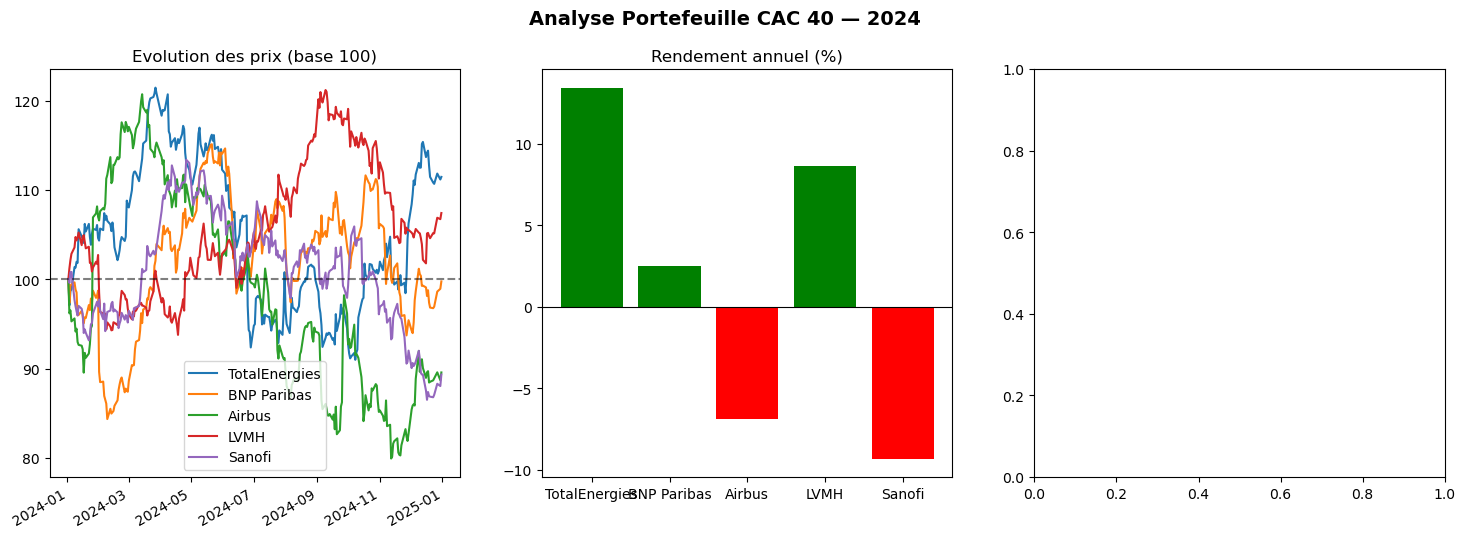

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Analyse Portefeuille CAC 40 — 2024', fontsize=14, fontweight='bold')

# Graphique 1 : Evolution des prix normalisés
(data / data.iloc[0] * 100).plot(ax=axes[0])
axes[0].set_title('Evolution des prix (base 100)')
axes[0].set_xlabel('')
axes[0].axhline(y=100, color='black', linestyle='--', alpha=0.5)

# Graphique 2 : Rendement vs Volatilité
colors = ['green' if r > 0 else 'red' for r in resume['Rendement annuel (%)']]
axes[1].bar(resume.index, resume['Rendement annuel (%)'], color=colors)
axes[1].set_title('Rendement annuel (%)')
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].tick

In [11]:
plt.savefig('analyse_cac40.png', dpi=150, bbox_inches='tight')
print("Graphique sauvegardé !")

Graphique sauvegardé !


<Figure size 640x480 with 0 Axes>

In [12]:
print("=" * 50)
print("   SYNTHÈSE PORTEFEUILLE CAC 40 — 2024")
print("=" * 50)

meilleur = resume['Rendement annuel (%)'].idxmax()
pire = resume['Rendement annuel (%)'].idxmin()
moins_volatile = resume['Volatilité annuelle (%)'].idxmin()

print(f"\n✅ Meilleure performance : {meilleur} ({resume.loc[meilleur, 'Rendement annuel (%)']:.2f}%)")
print(f"❌ Moins bonne performance : {pire} ({resume.loc[pire, 'Rendement annuel (%)']:.2f}%)")
print(f"📉 Moins volatile : {moins_volatile} ({resume.loc[moins_volatile, 'Volatilité annuelle (%)']:.2f}%)")

print("\nTableau complet :")
print(resume.to_string())
print("\n" + "=" * 50)

   SYNTHÈSE PORTEFEUILLE CAC 40 — 2024

✅ Meilleure performance : TotalEnergies (13.44%)
❌ Moins bonne performance : Sanofi (-9.31%)
📉 Moins volatile : LVMH (17.81%)

Tableau complet :
               Rendement annuel (%)  Volatilité annuelle (%)
TotalEnergies                 13.44                    23.23
BNP Paribas                    2.50                    23.29
Airbus                        -6.88                    28.66
LVMH                           8.65                    17.81
Sanofi                        -9.31                    19.16



In [13]:
readme = """# 📊 Analyse de Portefeuille — CAC 40 (2024)

## Description
Analyse financière de 5 actions du CAC 40 sur l'année 2024.
Projet réalisé dans le cadre de ma candidature en Master Finance de Marché.

## Actions analysées
- TotalEnergies (TTE)
- BNP Paribas (BNP)
- Airbus (AIR)
- LVMH (MC)
- Sanofi (SAN)

## Méthodologie
- Extraction des données via l'API Yahoo Finance (yfinance)
- Calcul des rendements quotidiens et annualisés
- Calcul de la volatilité annualisée (écart-type × √252)
- Visualisation : évolution des prix, rendements, volatilité

## Résultats clés (2024)
| Action | Rendement | Volatilité |
|---|---|---|
| TotalEnergies | +13.44% | 23.23% |
| BNP Paribas | +2.50% | 23.29% |
| Airbus | -6.88% | 28.66% |
| LVMH | +8.65% | 17.81% |
| Sanofi | -9.31% | 19.16% |

## Technologies utilisées
- Python 3
- pandas, yfinance, matplotlib, seaborn

## Auteure
**Ibtissem Lagha** — Diplomée en Licence Économie-Gestion  
Candidate Master Finance de Marché  
[LinkedIn](https://linkedin.com/in/ibtissem-lagha-741865336)
"""

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

print("README.md créé !")

README.md créé !


In [14]:
import os
print(os.getcwd())

/Users/ibtissem


In [15]:
import os
print(os.path.abspath('analyse_portefeuille_cac40.ipynb'))

/Users/ibtissem/analyse_portefeuille_cac40.ipynb


In [16]:
import shutil
import os

# Dossier destination GitHub
destination = '/Users/ibtissem/Documents/GitHub/analyse-portefeuille-cac40/'

# Copie des 3 fichiers
shutil.copy('analyse_portefeuille_cac40.ipynb', destination)
shutil.copy('analyse_cac40.png', destination)
shutil.copy('README.md', destination)

print("Fichiers copiés !")

FileNotFoundError: [Errno 2] No such file or directory: 'analyse_portefeuille_cac40.ipynb'

In [17]:
import os
print(os.listdir('/Users/ibtissem'))

['.Rhistory', '.config', 'Music', '.condarc', 'Untitled1.ipynb', '.DS_Store', 'git hup .ipynb', '.CFUserTextEncoding', '.xonshrc', 'anaconda_projects', 'Untitled.ipynb', '.zshrc', '.local', 'Pictures', 'analyse_cac40.png', 'exo open class room .ipynb', '.zsh_history', 'Untitled2.ipynb', '.ipython', 'Desktop', 'Library', '.matplotlib', 'README.md', '.cups', 'gemini exo .', 'Public', '.tcshrc', '.anaconda', 'Movies', '.Trash', '.ipynb_checkpoints', '.jupyter', 'Documents', '.bash_profile', 'Partie 2 op + exo chatgpt .ipynb', 'Downloads', '.continuum', '.gitconfig', '.zsh_sessions', '.conda']


In [18]:
import shutil

destination = '/Users/ibtissem/Documents/GitHub/analyse-portefeuille-cac40/'

shutil.copy('/Users/ibtissem/git hup .ipynb', destination + 'analyse_portefeuille_cac40.ipynb')
shutil.copy('/Users/ibtissem/analyse_cac40.png', destination)
shutil.copy('/Users/ibtissem/README.md', destination)


'/Users/ibtissem/Documents/GitHub/analyse-portefeuille-cac40/README.md'

In [19]:
import shutil, os

destination = '/Users/ibtissem/Documents/GitHub/esperance-de-vie-rstudio/'

shutil.copy('/mnt/user-data/uploads/projet__final_copie.R', destination + 'projet_final.R')
shutil.copy('/mnt/user-data/uploads/Life-Expectancy-Data-Updated.csv', destination)
shutil.copy('/mnt/user-data/uploads/projet_lagha_.pdf', destination + 'rapport_analyse.pdf')

print("Fichiers copiés !")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/uploads/projet__final_copie.R'

In [22]:
import subprocess
result = subprocess.run(['find', '/Users/ibtissem', '-name', '*.R', '-o', '-name', 'Life-Expectancy*'], 
                      capture_output=True, text=True)
print(result.stdout)

/Users/ibtissem/Library/Mobile Documents/com~apple~CloudDocs/Licence 3 Economie Gestion copie/S6/EN PLUS S6/Econométrie/RRRRRRRRR.R
/Users/ibtissem/Library/Mobile Documents/com~apple~CloudDocs/Licence 3 Economie Gestion copie/S6/EN PLUS S6/Projet econométrie.R
/Users/ibtissem/Library/Mobile Documents/com~apple~CloudDocs/Licence 3 Economie Gestion copie 2/S6/EN PLUS S6/Econométrie/RRRRRRRRR.R
/Users/ibtissem/Library/Mobile Documents/com~apple~CloudDocs/Licence 3 Economie Gestion copie 2/S6/EN PLUS S6/Projet econométrie.R
/Users/ibtissem/Library/Containers/com.microsoft.Word/Data/Library/Application Support/Microsoft/AppData/Microsoft/Office/16.0/OfficeFileCache/0/0/GUHGCNEPB4FJEMFJFLCJF4D3ENDNF2EA/e_APBHGOFGCIC4ELCAG4GWFVBEGQDFHPBJ.R
/Users/ibtissem/Library/Containers/com.microsoft.Word/Data/Library/Application Support/Microsoft/AppData/Microsoft/Office/16.0/OfficeFileCache/0/0/GUHGCNEPB4FJEMFJFLCJF4D3ENDNF2EA/e_DUGPE3DMAJEYAHAXGZHEGVHOHNE5GRAL.R
/Users/ibtissem/Library/Containers/c

In [ ]:
import os

dossiers = [
    '/Users/ibtissem/Downloads',
    '/Users/ibtissem/Desktop',
    '/Users/ibtissem/Documents'
]

for d in dossiers:
    if os.path.exists(d):
        fichiers = os.listdir(d)
        print(f"\n📁 {d} :")
        for f in fichiers:
            print(f"  - {f}")

In [26]:
import shutil

source = '/Users/ibtissem/Desktop/licence /L3 S5 et S6/S6/Science des données/final /sc/'
destination = '/Users/ibtissem/Documents/GitHub/esperance-de-vie-rstudio/'

# Voir ce qu'il y a dans ce dossier
import os
print(os.listdir(source))

PermissionError: [Errno 1] Operation not permitted: '/Users/ibtissem/Desktop/licence /L3 S5 et S6/S6/Science des données/final /sc/'

In [27]:
readme_r = """# 📊 Analyse de l'Espérance de Vie Mondiale (2000-2015)

## Description
Analyse statistique et modélisation de l'espérance de vie à partir d'une base de données mondiale.
Projet réalisé en Sciences des données — Licence Économie-Gestion (Université Évry-Val-d'Essonne).

## Données
- Source : Life Expectancy Data (OMS)
- 2864 observations, 11 variables
- Période : 2000-2015

## Méthodologie
- Nettoyage et préparation des données
- Analyse descriptive (boxplots, histogrammes, évolution temporelle)
- Matrice de corrélations (Pearson)
- Test ANOVA par région
- Modélisation : régression linéaire, log-linéaire, Lasso, Ridge, arbre de décision

## Résultats clés
- R² ajusté = 0.9545 (régression linéaire)
- Variable la plus influente : mortalité adulte (r = -0.945)
- Scolarisation : forte corrélation positive (r = 0.732)

## Technologies utilisées
- R, ggplot2, dplyr, glmnet, rpart, corrplot

## Auteure
**Ibtissem Lagha** — Étudiante en Licence Économie-Gestion  
Candidate Master Finance de Marché  
[LinkedIn](https://linkedin.com/in/ibtissem-lagha-741865336)
"""

with open('/Users/ibtissem/Documents/GitHub/esperance-de-vie-rstudio/README.md', 'w', encoding='utf-8') as f:
    f.write(readme_r)

print("README créé !")

README créé !
